# Bias–Variance Tradeoff - BRYAN MONTAGUANO

## Setup

If you are running this notebook for the first time, install the required libraries by running the cell below.

# Run this only once if you get a ModuleNotFoundError
!pip install numpy matplotlib scikit-learn


---

To understand this concept, we trained polynomial regression models of different degrees on noisy sine data and observed how they behave.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Generate Data

We generate noisy observations from **y = sin(x)**, adding Gaussian noise (σ = 0.3) to simulate real-world data.

In [12]:
X = np.linspace(-3, 3, 60)
y = np.sin(X) + np.random.normal(0, 0.3, 60)

X_plot = np.linspace(-3, 3, 300)
y_true = np.sin(X_plot)

## Polynomial Regression — Degree 1, 4, and 25

We fit three models to see how complexity affects the predictions.

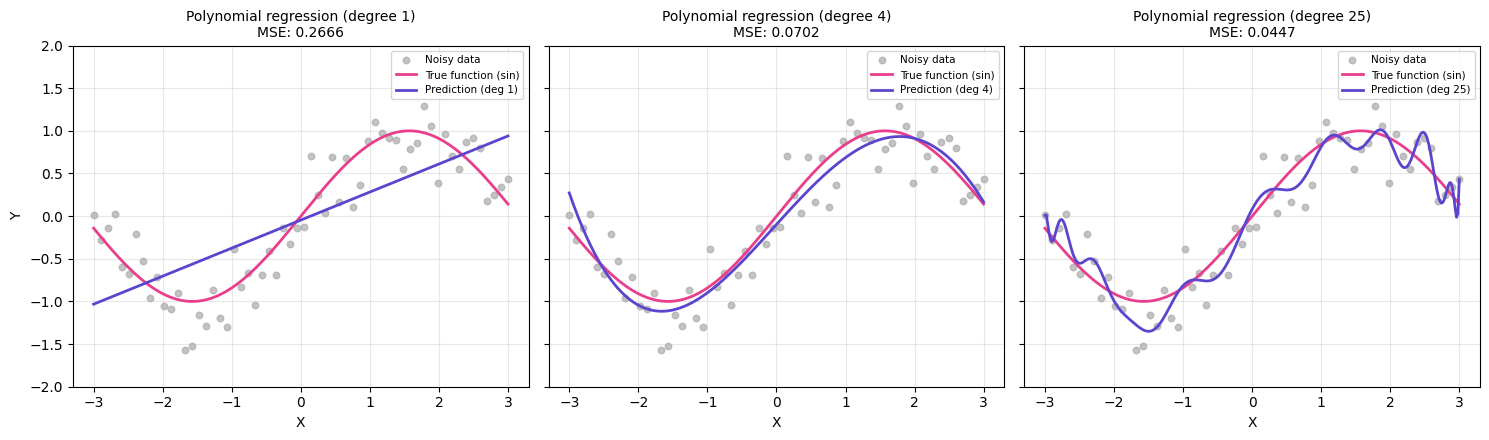

In [13]:
degrees = [1, 4, 25]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, d in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X.reshape(-1,1), y)
    mse = mean_squared_error(y, model.predict(X.reshape(-1,1)))

    ax.scatter(X, y, color='#aaaaaa', s=22, alpha=0.7, label='Noisy data')
    ax.plot(X_plot, y_true, color='#E83E8C', lw=2, label='True function (sin)')
    ax.plot(X_plot, model.predict(X_plot.reshape(-1,1)), color='#5B45CF', lw=2, label=f'Prediction (deg {d})')
    ax.set_title(f'Polynomial regression (degree {d})\nMSE: {mse:.4f}', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Y')
plt.tight_layout()
plt.show()

## Analysis

**Degree 1 — High Bias (Underfitting)**

The model is too simple. A straight line cannot capture the shape of a sine wave, so it makes systematic errors regardless of the data. This is called **high bias** — the model has a wrong assumption about the data.

**Degree 4 — Balanced (Sweet Spot)**

The model is complex enough to follow the true function without chasing noise. This is the best case: low bias and low variance.

**Degree 25 — High Variance (Overfitting)**

The model is too flexible. It memorizes the noise in the training data and creates wiggles that don't represent the real pattern. This is called **high variance** — small changes in the data produce very different predictions.

## Bias–Variance Tradeoff Curve

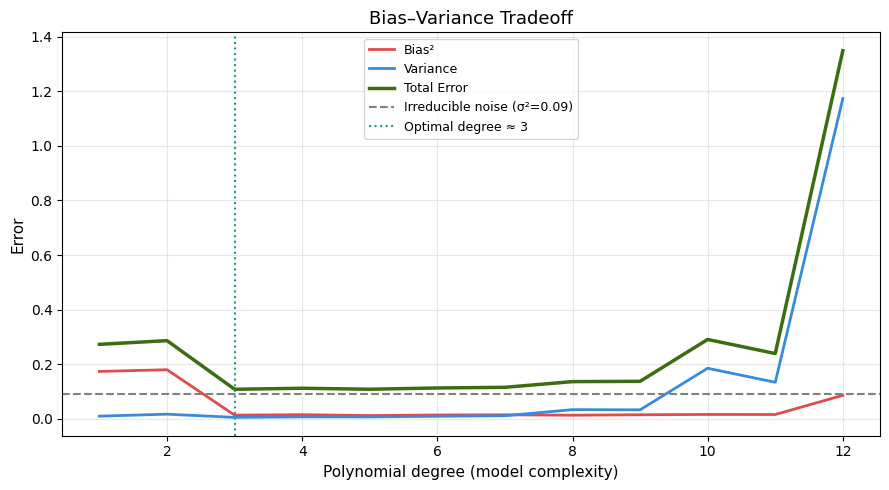

Optimal degree: 3


In [14]:
# Estimate Bias² and Variance using bootstrap sampling
x_eval = np.linspace(-3, 3, 100)
y_eval = np.sin(x_eval)
sigma2 = 0.09  # irreducible noise

all_degrees = list(range(1, 13))
b2_list, var_list, total_list = [], [], []

for d in all_degrees:
    preds = np.zeros((100, len(x_eval)))
    for b in range(100):
        idx = np.random.choice(len(X), len(X), replace=True)
        m = make_pipeline(PolynomialFeatures(d), LinearRegression())
        m.fit(X[idx].reshape(-1,1), y[idx])
        preds[b] = m.predict(x_eval.reshape(-1,1))
    mean_pred = preds.mean(axis=0)
    bi2 = np.mean((mean_pred - y_eval)**2)
    va  = np.mean(preds.var(axis=0))
    b2_list.append(bi2)
    var_list.append(va)
    total_list.append(bi2 + va + sigma2)

best = all_degrees[np.argmin(total_list)]

plt.figure(figsize=(9, 5))
plt.plot(all_degrees, b2_list,    color='#E24B4A', lw=2,   label='Bias²')
plt.plot(all_degrees, var_list,   color='#378ADD', lw=2,   label='Variance')
plt.plot(all_degrees, total_list, color='#3B6D11', lw=2.5, label='Total Error')
plt.axhline(sigma2, color='gray', lw=1.5, ls='--', label=f'Irreducible noise (σ²={sigma2})')
plt.axvline(best, color='#1D9E75', lw=1.5, ls=':', label=f'Optimal degree ≈ {best}')
plt.xlabel('Polynomial degree (model complexity)', fontsize=11)
plt.ylabel('Error', fontsize=11)
plt.title('Bias–Variance Tradeoff', fontsize=13)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal degree: {best}')

## Conclusion

| Model | Bias | Variance | Problem |
|---|---|---|---|
| Degree 1 | High | Low | Underfitting |
| Degree 4 | Low | Low | Best model |
| Degree 25 | Low | High | Overfitting |

The key idea is that increasing model complexity always reduces bias but increases variance. The best model is the one that finds the right balance between the two — not too simple, not too complex.

This is why we don't just pick the model with the lowest training error. A very complex model will always fit the training data well, but it will fail on new data.